--- Kiểm tra giá trị thiếu ---
order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64

--- Thống kê tổng quan ---
Tổng số đơn hàng: 3,214,874
Tổng số sản phẩm khác nhau: 49,677
Số lượng sản phẩm trung bình mỗi đơn hàng: 10.09


C:\Users\TNP\AppData\Local\Temp\ipykernel_29964\3921935659.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')


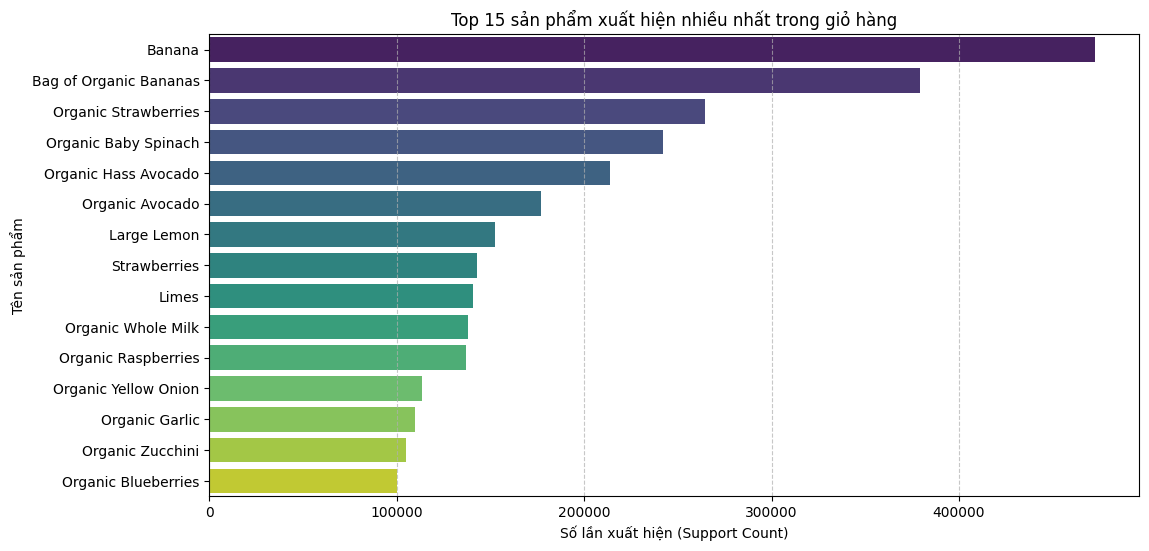

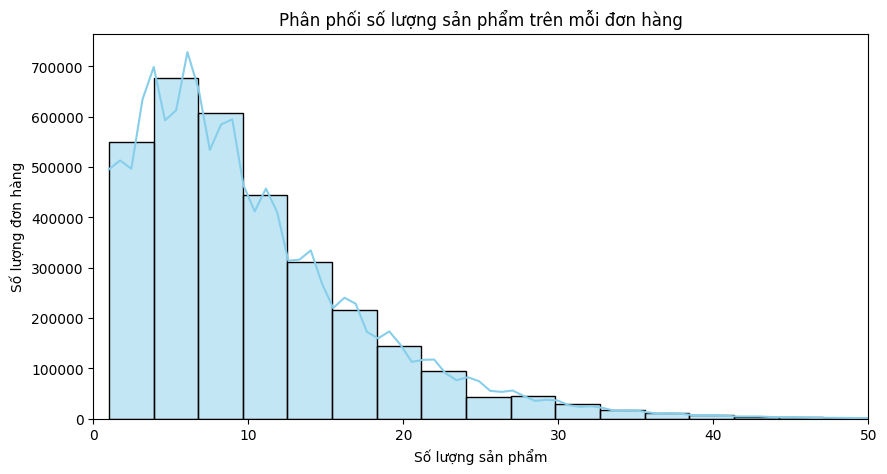

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

order_products = pd.read_csv('../data/raw/order_products__prior.csv')
products = pd.read_csv('../data/raw/products.csv')

print("--- Kiểm tra giá trị thiếu ---")
print(order_products.isnull().sum())

n_orders = order_products['order_id'].nunique()
n_products = order_products['product_id'].nunique()
avg_basket_size = order_products.groupby('order_id')['product_id'].count().mean()

print(f"\n--- Thống kê tổng quan ---")
print(f"Tổng số đơn hàng: {n_orders:,}")
print(f"Tổng số sản phẩm khác nhau: {n_products:,}")
print(f"Số lượng sản phẩm trung bình mỗi đơn hàng: {avg_basket_size:.2f}")

df_merged = pd.merge(order_products, products, on='product_id', how='left')

top_products = df_merged['product_name'].value_counts().head(15)


plt.figure(figsize=(12, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')
plt.title('Top 15 sản phẩm xuất hiện nhiều nhất trong giỏ hàng')
plt.xlabel('Số lần xuất hiện (Support Count)')
plt.ylabel('Tên sản phẩm')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


basket_sizes = order_products.groupby('order_id')['product_id'].count()
plt.figure(figsize=(10, 5))
sns.histplot(basket_sizes, bins=50, kde=True, color='skyblue')
plt.title('Phân phối số lượng sản phẩm trên mỗi đơn hàng')
plt.xlabel('Số lượng sản phẩm')
plt.ylabel('Số lượng đơn hàng')
plt.xlim(0, 50)
plt.show()

In [2]:
import pandas as pd
import os


raw_data_path = '../data/raw/'
processed_data_path = '../data/processed/'


if not os.path.exists(processed_data_path):
    os.makedirs(processed_data_path)
    print(f"Đã tạo thư mục: {processed_data_path}")

print("Đang tải dữ liệu...")

order_products = pd.read_csv(os.path.join(raw_data_path, 'order_products__prior.csv'))
products = pd.read_csv(os.path.join(raw_data_path, 'products.csv'))
orders = pd.read_csv(os.path.join(raw_data_path, 'orders.csv'))


subset_size = 500000 
order_products_sample = order_products.head(subset_size).copy()


df_apriori = pd.merge(order_products_sample, products[['product_id', 'product_name']], 
                    on='product_id', how='left')


df_gnn = pd.merge(order_products_sample, orders[['order_id', 'user_id']], 
                on='order_id', how='left')

print("Đang lưu dữ liệu vào data/processed...")
df_apriori.to_csv(os.path.join(processed_data_path, 'apriori_input.csv'), index=False)
df_gnn[['user_id', 'product_id']].to_csv(os.path.join(processed_data_path, 'gnn_edge_list.csv'), index=False)

print("--- HOÀN THÀNH ---")

Đang tải dữ liệu...
Đang lưu dữ liệu vào data/processed...
--- HOÀN THÀNH ---


# Sau khi preprocess

--- Thống kê cho Apriori/FP-Growth ---
Tổng số dòng: 500,000
Số lượng đơn hàng duy nhất: 49,626
Số lượng sản phẩm duy nhất: 29,182
Kích thước giỏ hàng trung bình: 10.08
Giỏ hàng lớn nhất: 92

--- Thống kê cho GNN (User-Item Interaction) ---
Số lượng người dùng duy nhất: 39,834
Số lượng tương tác (cạnh): 500,000
Số sản phẩm trung bình mỗi người mua: 12.55
Độ thưa của đồ thị (Sparsity): 99.96%


C:\Users\TNP\AppData\Local\Temp\ipykernel_29964\4268503415.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')


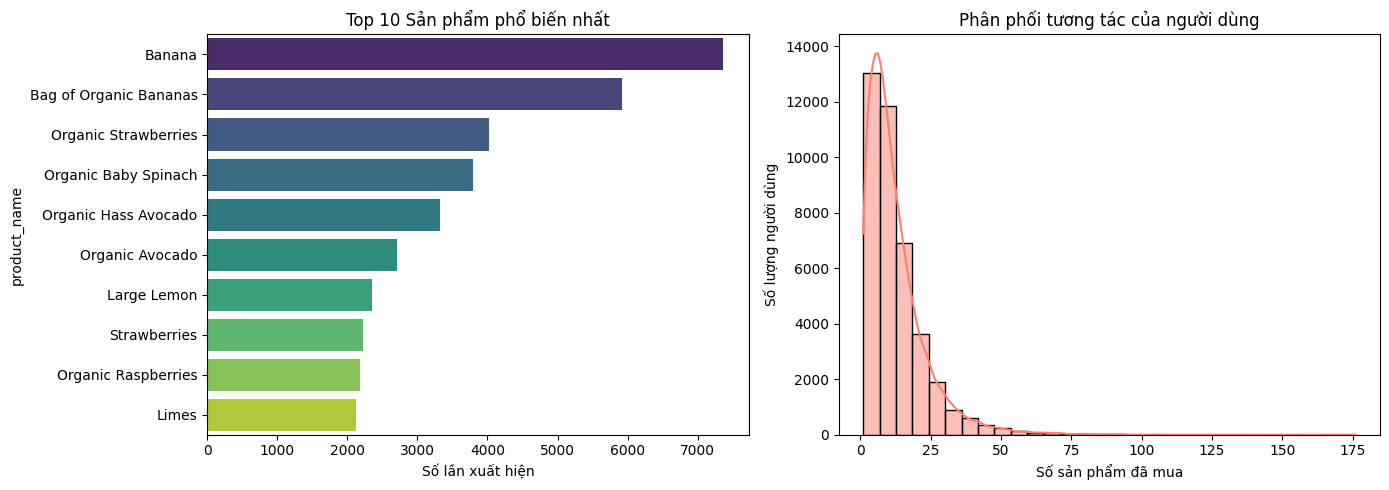

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

apriori_df = pd.read_csv('../data/processed/apriori_input.csv')
gnn_df = pd.read_csv('../data/processed/gnn_edge_list.csv')


print("--- Thống kê cho Apriori/FP-Growth ---")
n_orders = apriori_df['order_id'].nunique()
n_products = apriori_df['product_id'].nunique()
basket_sizes = apriori_df.groupby('order_id')['product_id'].count()

print(f"Tổng số dòng: {len(apriori_df):,}")
print(f"Số lượng đơn hàng duy nhất: {n_orders:,}")
print(f"Số lượng sản phẩm duy nhất: {n_products:,}")
print(f"Kích thước giỏ hàng trung bình: {basket_sizes.mean():.2f}")
print(f"Giỏ hàng lớn nhất: {basket_sizes.max()}")


print("\n--- Thống kê cho GNN (User-Item Interaction) ---")
n_users = gnn_df['user_id'].nunique()
user_interactions = gnn_df.groupby('user_id')['product_id'].count()

sparsity = 1 - (len(gnn_df) / (n_users * n_products))

print(f"Số lượng người dùng duy nhất: {n_users:,}")
print(f"Số lượng tương tác (cạnh): {len(gnn_df):,}")
print(f"Số sản phẩm trung bình mỗi người mua: {user_interactions.mean():.2f}")
print(f"Độ thưa của đồ thị (Sparsity): {sparsity * 100:.2f}%")


plt.figure(figsize=(14, 5))


plt.subplot(1, 2, 1)
top_products = apriori_df['product_name'].value_counts().head(10)
sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')
plt.title('Top 10 Sản phẩm phổ biến nhất')
plt.xlabel('Số lần xuất hiện')


plt.subplot(1, 2, 2)
sns.histplot(user_interactions, bins=30, kde=True, color='salmon')
plt.title('Phân phối tương tác của người dùng')
plt.xlabel('Số sản phẩm đã mua')
plt.ylabel('Số lượng người dùng')

plt.tight_layout()
plt.show()